In [2]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [3]:
#Gibbs energy dist from beta = 1 case, from the RSJJ model calculation value, single mode coup 1 gamma 1.4
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([3,3,2])

#Gibbs state with the degeneracy (Ergodic restriction concerned)
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div
            
            sys_gibbs.append(make_matrix_dim)
            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == False:
            return ret_matrix
        if TF == True:
            return sys_gibbs

    else:
        print("Not available input source")
        return None

In [4]:
'''
def slicing_Func(Mat):
    if Mat.shape[0] == Mat.shape[1]:
        arr = []
        for i in range(Mat.shape[0]):
            index = 0
            for j in range(Mat.shape[0]):
                if i==j and index < 2:
                    if Mat[index][index] != Mat[index+1][index+1]:
                        arr.append(index)
                        index += 1
                        break
    return(arr)
'''

Cal_Gibbs = degen_Gibbs_create(Gibbs,degeneracy,True)
Cal_Gibbs
#print(Cal_Gibbs)

[array([[ 0.195,  0.   ,  0.   ],
        [ 0.   ,  0.195,  0.   ],
        [ 0.   ,  0.   ,  0.195]]),
 array([[ 0.093,  0.   ,  0.   ],
        [ 0.   ,  0.093,  0.   ],
        [ 0.   ,  0.   ,  0.093]]),
 array([[ 0.069,  0.   ],
        [ 0.   ,  0.069]])]

In [5]:
#Create Qubit system with coherence
asdf = coherent_dm(2,0.1+0.2j)
Nup_asdf = asdf.full()

c = Bloch()

pointx = expect(sigmax(), asdf)
pointy = expect(sigmay(), asdf)
pointz = expect(sigmaz(), asdf)

c.add_points([pointx, pointy, pointz])
c.add_vectors([pointx, pointy, pointz])

In [5]:
#System construction, False case
Nup_asdf_qobj = Qobj(Nup_asdf)
Cal_Gibbs_qobj = Qobj(Cal_Gibbs)
rhoRS_qutip = tensor(Nup_asdf_qobj, Cal_Gibbs_qobj)
rhoRS=rhoRS_qutip.full()

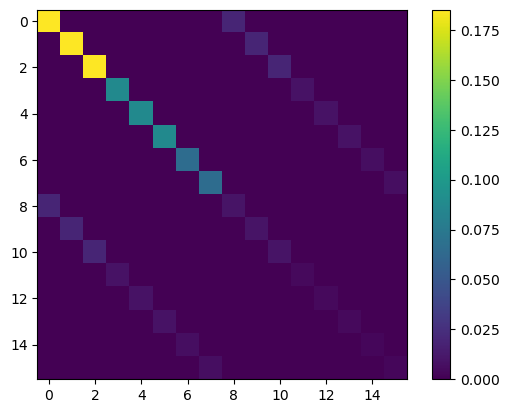

In [6]:
plt.imshow(rhoRS.real,cmap='viridis')
plt.colorbar()

In [6]:
#System construction, True case
Nup_asdf = np.reshape(Nup_asdf,(4))

Block1_1 = Nup_asdf[0] * Cal_Gibbs[1]
Block1_2 = Nup_asdf[1] * Cal_Gibbs[1]
Block2_1 = Nup_asdf[0] * Cal_Gibbs[0]
Block2_2 = Nup_asdf[1] * Cal_Gibbs[0]
'''
summa = []

for i in range(2):
    for j in range(2):
        summa.append(globals()["Block{}_{}".format(i+1,j+1)])
'''

asdfasdf = np.zeros((6,6))
asdfasdf[:3,:3] = np.matrix(Block1_1)
asdfasdf[3:6,:3] = np.matrix(Block1_2)
asdfasdf[:3,3:6] = np.matrix(Block2_1)
asdfasdf[3:6,3:6] = np.matrix(Block2_2)

asdfasdf

C:\Users\sky12\AppData\Local\Temp\ipykernel_17248\2344484902.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  asdfasdf[:3,:3] = np.matrix(Block1_1)
C:\Users\sky12\AppData\Local\Temp\ipykernel_17248\2344484902.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  asdfasdf[3:6,:3] = np.matrix(Block1_2)
C:\Users\sky12\AppData\Local\Temp\ipykernel_17248\2344484902.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  asdfasdf[:3,3:6] = np.matrix(Block2_1)
C:\Users\sky12\AppData\Local\Temp\ipykernel_17248\2344484902.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  asdfasdf[3:6,3:6] = np.matrix(Block2_2)


array([[ 0.088,  0.   ,  0.   ,  0.185,  0.   ,  0.   ],
       [ 0.   ,  0.088,  0.   ,  0.   ,  0.185,  0.   ],
       [ 0.   ,  0.   ,  0.088,  0.   ,  0.   ,  0.185],
       [ 0.009,  0.   ,  0.   ,  0.019,  0.   ,  0.   ],
       [ 0.   ,  0.009,  0.   ,  0.   ,  0.019,  0.   ],
       [ 0.   ,  0.   ,  0.009,  0.   ,  0.   ,  0.019]])

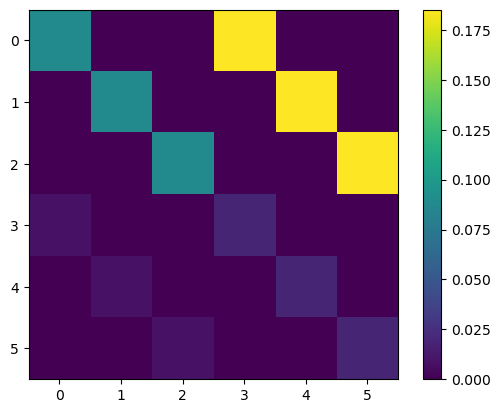

In [7]:
plt.imshow(asdfasdf,cmap='viridis')
plt.colorbar()